In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)



In [ ]:

df = pd.read_csv('/ks-projects-201612.csv', encoding='latin1', low_memory=False)

df.columns = df.columns.str.strip()

print(f'Dataset chargé : {df.shape[0]:,} lignes, {df.shape[1]} colonnes')
df.head()

Dataset chargé : 323,750 lignes, 17 colonnes


,ID,name,category,main_category,currency,deadline,goal,launched,pledged,state,backers,country,usd pledged,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16
0,1000002330,The Songs of Adelaide & Abullah,Poetry,Publishing,GBP,2015-10-09 11:36:00,1000,2015-08-11 12:12:28,0,failed,0,GB,0,NaN,NaN,NaN,NaN
1,1000004038,Where is Hank?,Narrative Film,Film & Video,USD,2013-02-26 00:20:50,45000,2013-01-12 00:20:50,220,failed,3,US,220,NaN,NaN,NaN,NaN
2,1000007540,ToshiCapital Rekordz Needs Help to Complete Album,Music,Music,USD,2012-04-16 04:24:11,5000,2012-03-17 03:24:11,1,failed,1,US,1,NaN,NaN,NaN,NaN
3,1000011046,Community Film Project: The Art of Neighborhoo...,Film & Video,Film & Video,USD,2015-08-29 01:00:00,19500,2015-07-04 08:35:03,1283,canceled,14,US,1283,NaN,NaN,NaN,NaN
4,1000014025,Monarch Espresso Bar,Restaurants,Food,USD,2016-04-01 13:38:27,50000,2016-02-26 13:38:27,52375,successful,224,US,52375,NaN,NaN,NaN,NaN


In [ ]:

cols_to_drop = ['ID', 'pledged', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16']
df.drop(columns=cols_to_drop, inplace=True)

df.rename(columns={'usd pledged': 'usd_pledged'}, inplace=True)

print('Colonnes restantes :', df.columns.tolist())

Colonnes restantes : ['name', 'category', 'main_category', 'currency', 'deadline', 'goal', 'launched', 'state', 'backers', 'country', 'usd_pledged']


In [ ]:
print('Valeurs manquantes par colonne :')
print(df.isnull().sum())

df.dropna(subset=['name', 'category'], inplace=True)


df['usd_pledged'] = df['usd_pledged'].fillna(0)

print(f'\nAprès nettoyage NaN : {df.shape[0]:,} lignes')

Valeurs manquantes par colonne :
name                4
category            5
main_category       0
currency            0
deadline            0
goal                0
launched            0
state               0
backers             0
country             0
usd_pledged      3790
dtype: int64

Après nettoyage NaN : 323,741 lignes


In [ ]:

print('Distribution des états avant filtrage :')
print(df['state'].value_counts().head(10))

df = df[df['state'].isin(['successful', 'failed'])].copy()

df['target'] = (df['state'] == 'successful').astype(int)

print(f'\nAprès filtrage : {df.shape[0]:,} lignes')
print(f"Taux de succès : {df['target'].mean():.1%}")

Distribution des états avant filtrage :
state
failed        168218
successful    113081
canceled       32354
live            4428
undefined       3555
suspended       1478
0                 96
1                 15
25                11
5                 10
Name: count, dtype: int64

Après filtrage : 281,299 lignes
Taux de succès : 40.2%


In [ ]:

df['deadline'] = pd.to_datetime(df['deadline'])
df['launched'] = pd.to_datetime(df['launched'])


print(df[['launched', 'deadline']].dtypes)
df[['launched', 'deadline']].head()

launched    datetime64[ns]
deadline    datetime64[ns]
dtype: object


,launched,deadline
0,2015-08-11 12:12:28,2015-10-09 11:36:00
1,2013-01-12 00:20:50,2013-02-26 00:20:50
2,2012-03-17 03:24:11,2012-04-16 04:24:11
4,2016-02-26 13:38:27,2016-04-01 13:38:27
5,2014-12-01 18:30:44,2014-12-21 18:30:44


In [ ]:

df['duration_days'] = (df['deadline'] - df['launched']).dt.days

df['name_length'] = df['name'].str.len()


df['launch_year']  = df['launched'].dt.year
df['launch_month'] = df['launched'].dt.month


df = df[(df['duration_days'] > 0) & (df['duration_days'] <= 60)]

print('Features créées :', ['duration_days', 'name_length', 'launch_year', 'launch_month'])
df[['duration_days', 'name_length', 'launch_year', 'launch_month']].describe()

Features créées : ['duration_days', 'name_length', 'launch_year', 'launch_month']


,duration_days,name_length,launch_year,launch_month
count,276776.000000,276776.000000,276776.000000,276776.000000
mean,33.228047,33.993634,2013.760160,6.385796
std,11.499015,15.928140,1.645223,3.269798
min,1.000000,1.000000,2009.000000,1.000000
25%,30.000000,20.000000,2013.000000,4.000000
50%,30.000000,33.000000,2014.000000,6.000000
75%,35.000000,48.000000,2015.000000,9.000000
max,60.000000,85.000000,2016.000000,12.000000


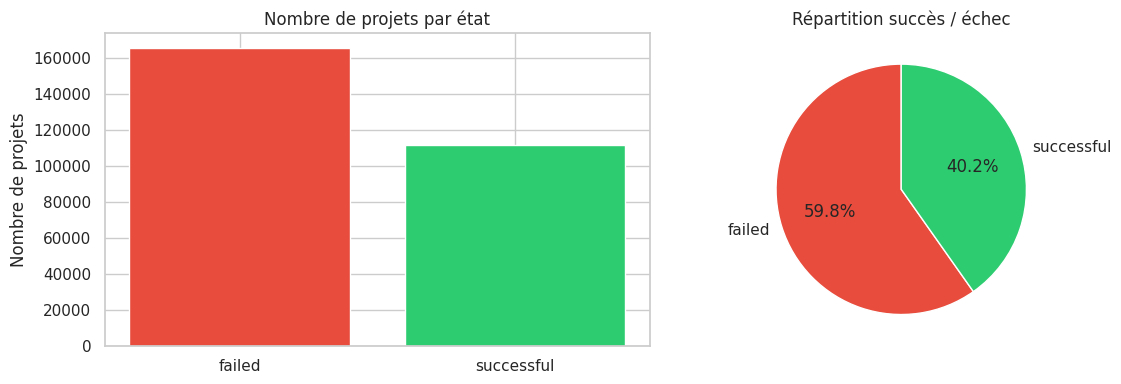

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['state'].value_counts()
axes[0].bar(counts.index, counts.values, color=['#e74c3c', '#2ecc71'])
axes[0].set_title('Nombre de projets par état')
axes[0].set_ylabel('Nombre de projets')

axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=['#e74c3c', '#2ecc71'], startangle=90)
axes[1].set_title('Répartition succès / échec')

plt.tight_layout()
plt.show()

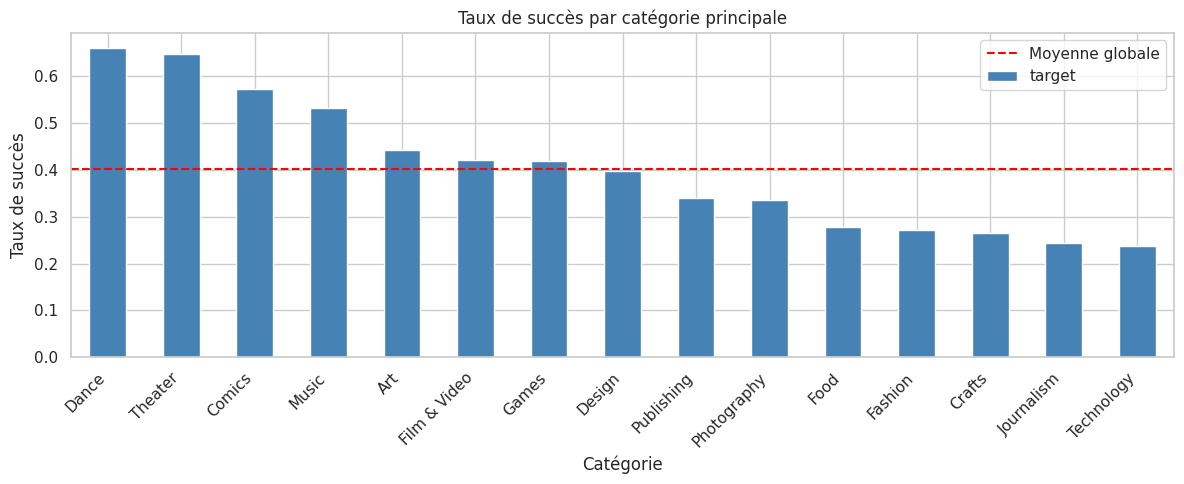

In [ ]:

cat_success = df.groupby('main_category')['target'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
cat_success.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Taux de succès par catégorie principale')
plt.ylabel('Taux de succès')
plt.xlabel('Catégorie')
plt.xticks(rotation=45, ha='right')
plt.axhline(df['target'].mean(), color='red', linestyle='--', label='Moyenne globale')
plt.legend()
plt.tight_layout()
plt.show()

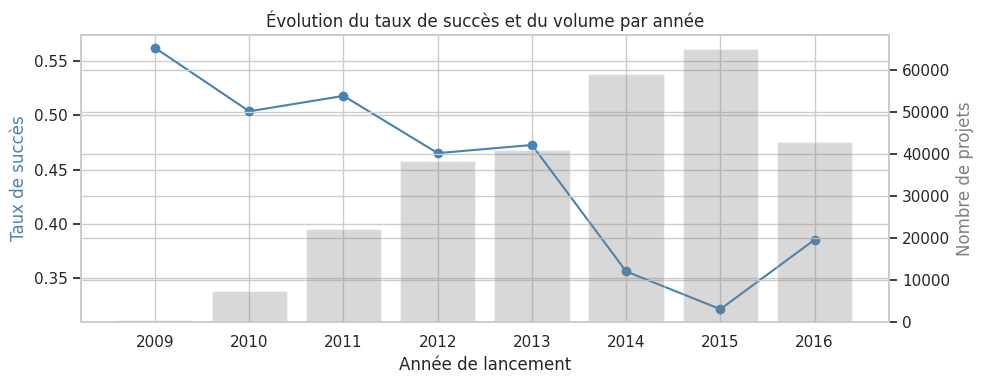

In [ ]:
year_success = df.groupby('launch_year')['target'].agg(['mean', 'count'])

fig, ax1 = plt.subplots(figsize=(10, 4))
ax2 = ax1.twinx()

ax1.plot(year_success.index, year_success['mean'], 'o-', color='steelblue', label='Taux succès')
ax2.bar(year_success.index, year_success['count'], alpha=0.3, color='gray', label='Nb projets')

ax1.set_xlabel('Année de lancement')
ax1.set_ylabel('Taux de succès', color='steelblue')
ax2.set_ylabel('Nombre de projets', color='gray')
plt.title('Évolution du taux de succès et du volume par année')
plt.tight_layout()
plt.show()

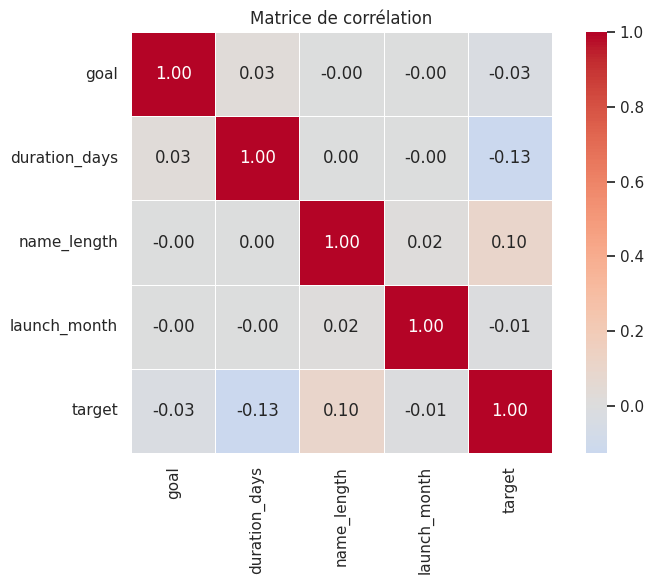

In [ ]:

num_cols = ['goal', 'duration_days', 'name_length', 'launch_month', 'target']
corr = df[num_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Matrice de corrélation')
plt.tight_layout()
plt.show()

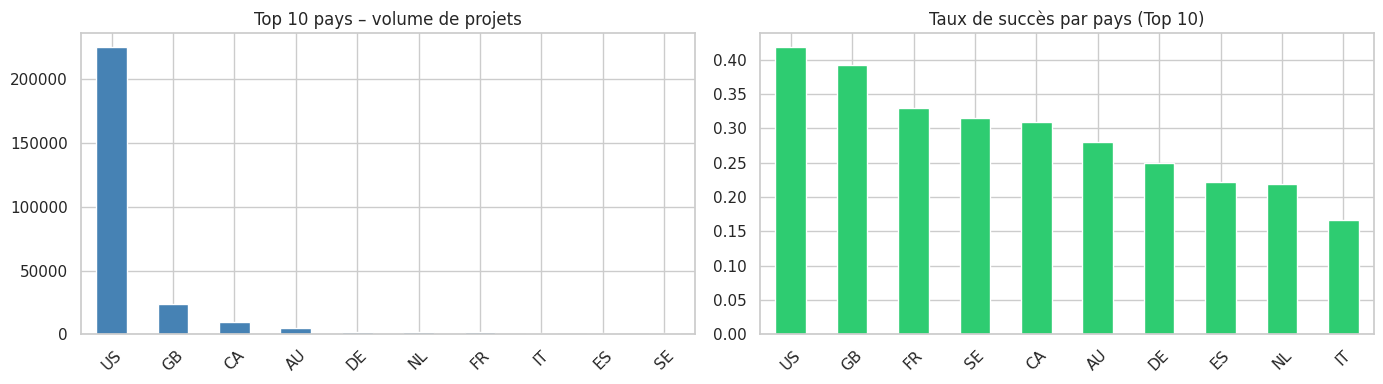

In [ ]:
top_countries = df['country'].value_counts().head(10)

country_success = df[df['country'].isin(top_countries.index)]\
    .groupby('country')['target'].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

top_countries.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Top 10 pays – volume de projets')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=45)

country_success.sort_values(ascending=False).plot(
    kind='bar', ax=axes[1], color='#2ecc71', edgecolor='white')
axes[1].set_title('Taux de succès par pays (Top 10)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
print('='*50)
print('RÉSUMÉ DU DATASET NETTOYÉ')
print('='*50)
print(f'Lignes totales       : {df.shape[0]:,}')
print(f'Colonnes             : {df.shape[1]}')
print(f'Projets réussis      : {df["target"].sum():,} ({df["target"].mean():.1%})')
print(f'Projets échoués      : {(df["target"]==0).sum():,} ({1-df["target"].mean():.1%})')
print(f'Catégories           : {df["main_category"].nunique()}')
print(f'Pays                 : {df["country"].nunique()}')
print(f'Période              : {df["launched"].min().year} → {df["deadline"].max().year}')
print()
print('Colonnes disponibles :')
for col in df.columns:
    print(f'  - {col} ({df[col].dtype})')

RÉSUMÉ DU DATASET NETTOYÉ
Lignes totales       : 276,776
Colonnes             : 16
Projets réussis      : 111,325 (40.2%)
Projets échoués      : 165,451 (59.8%)
Catégories           : 15
Pays                 : 22
Période              : 2009 → 2016

Colonnes disponibles :
  - name (object)
  - category (object)
  - main_category (object)
  - currency (object)
  - deadline (datetime64[ns])
  - goal (object)
  - launched (datetime64[ns])
  - state (object)
  - backers (object)
  - country (object)
  - usd_pledged (object)
  - target (int64)
  - duration_days (int64)
  - name_length (int64)
  - launch_year (int32)
  - launch_month (int32)


In [ ]:

df_clean = df.drop(columns=['deadline', 'launched', 'state'])

df_clean.to_csv('kickstarter_clean.csv', index=False)
print(f'✅ Dataset exporté : kickstarter_clean.csv ({df_clean.shape[0]:,} lignes, {df_clean.shape[1]} colonnes)')
print()
print('Colonnes exportées :')
print(df_clean.columns.tolist())

✅ Dataset exporté : kickstarter_clean.csv (276,776 lignes, 13 colonnes)

Colonnes exportées :
['name', 'category', 'main_category', 'currency', 'goal', 'backers', 'country', 'usd_pledged', 'target', 'duration_days', 'name_length', 'launch_year', 'launch_month']
